# Using Gambit with SageMath: extensive form games

A strategic form game is a table of payoffs. An **extensive form game** is a tree: players move in sequence, chance may intervene, and a player may be unable to tell apart the situations they find themselves in.

SageMath's `ExtensiveFormGame` is a thin layer over Gambit's tree games. The tree itself, the information sets, and the equilibrium solvers are all Gambit's; what Sage adds is its own notation, exact rational arithmetic, plotting, and the rest of a computer algebra system.

This tutorial builds a few trees, walks through the interface, and ends with a puzzle that Gambit's solvers deliberately refuse to answer — and that Sage can settle exactly.

The companion tutorial [Using Gambit with SageMath: strategic form games](sagemath_normal_form.ipynb) covers `NormalFormGame` and the strategic form interface.

> **Requirements.** As for the companion tutorial: a SageMath build containing [sagemath/sage#42367](https://github.com/sagemath/sage/pull/42367), the optional `pygambit` package, and the **SageMath kernel**.
> The `gtdraw` section additionally needs the optional `gtdraw` package and a LaTeX installation.

In [1]:
from fractions import Fraction

import pygambit as gbt

## Building a tree

We build the Battle of the Sexes as a sequential game: Amy chooses first, Bob sees what she chose and responds.

Two things are worth knowing before we start. Nodes carry **no labels** — following Gambit, a node is identified by the path of action labels leading to it, so `root.children['game']` is the node reached when Amy plays `game`. And an outcome is attached with `set_outcome`, which takes a label and the list of payoffs.

In [2]:
battle = ExtensiveFormGame(players=["Amy", "Bob"])
battle.append_move(battle.root, "Amy", ["game", "movie"])

for choice in ["game", "movie"]:
    battle.append_move(battle.root.children[choice], "Bob", ["game", "movie"])

payoffs = {("game", "game"): [3, 2], ("game", "movie"): [1, 1],
           ("movie", "game"): [0, 0], ("movie", "movie"): [2, 3]}

for (amy, bob), payoff in payoffs.items():
    battle.set_outcome(battle.root.children[amy].children[bob],
                       f"{amy},{bob}", payoff)

battle

An extensive form game with 2 players

Because Bob observes Amy's choice, he is at a different decision point in each branch. That gives three information sets — one for Amy and one for each of Bob's two nodes — each containing a single node.

In [3]:
len(battle.infosets), sorted(len(list(s.members)) for s in battle.infosets)

(3, [1, 1, 1])

## Drawing the tree

`plot` draws the tree. The default backend uses Sage's own graphics, so it works anywhere Sage does.

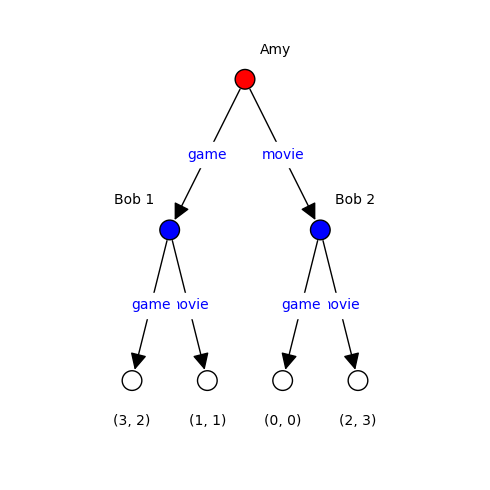

In [4]:
battle.plot(backend="sage")

The `'gtdraw'` backend instead produces a TikZ picture, which is what you want for a paper: it is vector output with real LaTeX typesetting. It returns a picture object that can be rendered to PDF, SVG or PNG, or whose LaTeX source you can paste into a document.

In [5]:
picture = battle.plot(backend="gtdraw")
print("\n".join(picture.content().splitlines()[:6]))

% TikZ code with built-in styling for game trees
% TikZ libraries required for game trees
\usetikzlibrary{shapes}
\usetikzlibrary{arrows.meta}

% Style settings for game tree formatting


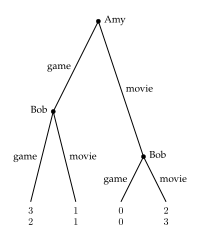

In [6]:
from IPython.display import SVG

SVG(filename=picture.svg(view=False))

## Information sets

Now suppose Amy and Bob choose *simultaneously*. The tree is the same shape, but Bob no longer knows which branch he is in: his two nodes have to be bundled into a single information set.

`append_infoset` does that. Instead of giving Bob a fresh move at the second node, we say that the node belongs to the same information set as an existing one.

In [7]:
simultaneous = ExtensiveFormGame(players=["Amy", "Bob"])
simultaneous.append_move(simultaneous.root, "Amy", ["game", "movie"])
simultaneous.append_move(simultaneous.root.children["game"], "Bob",
                         ["game", "movie"])
simultaneous.append_infoset(simultaneous.root.children["movie"],
                            simultaneous.root.children["game"])

for (amy, bob), payoff in payoffs.items():
    simultaneous.set_outcome(simultaneous.root.children[amy].children[bob],
                             f"{amy},{bob}", payoff)

len(simultaneous.infosets), sorted(len(list(s.members))
                                   for s in simultaneous.infosets)

(2, [1, 2])

Two information sets now, one of which contains two nodes. Sage can also confirm that the game has perfect recall, meaning no player ever forgets something they previously knew — an assumption every one of Gambit's solvers relies on.

In [8]:
simultaneous.is_perfect_recall

True

That single change to the information structure changes the answer.
`obtain_nash` sends the game to a Gambit solver and hands back equilibria as behaviour profiles; we read off what each is worth to each player, exactly, with `QQ`.

In [9]:
def payoff_table(game, equilibria):
    return [[QQ(eq.payoff(player)) for player in game.players]
            for eq in equilibria]


print("sequential  ", payoff_table(battle,
                                   battle.obtain_nash(algorithm="enumpure")))
print("simultaneous", payoff_table(simultaneous,
                                   simultaneous.obtain_nash(algorithm="enumpure")))

sequential   [[3, 2], [3, 2], [2, 3]]
simultaneous [[3, 2], [2, 3]]


When Bob moves second he can condition on Amy's choice, and there are three pure equilibria (two of which end at the same outcome). When the players move simultaneously, only two survive.

## Chance moves

Real games often start with a deal, a roll, or some other move by nature. `append_chance_move` adds one, with exact rational probabilities.

Here is a miniature poker game. Nature deals Alice a high or low card. Alice sees it and either bets or checks. Bob does *not* see the card — his two nodes go into one information set — and either calls or folds.

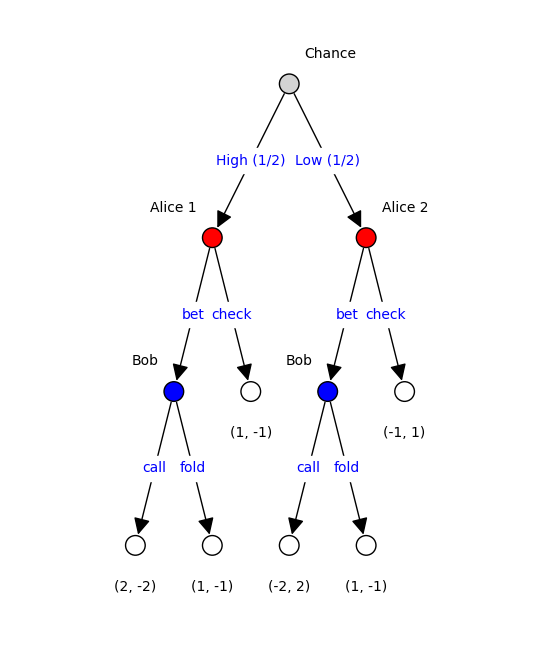

In [10]:
poker = ExtensiveFormGame(players=["Alice", "Bob"])
poker.append_chance_move(poker.root, ["High", "Low"], [1/2, 1/2])

for card in ["High", "Low"]:
    poker.append_move(poker.root.children[card], "Alice", ["bet", "check"])

poker.append_move(poker.root.children["High"].children["bet"], "Bob",
                  ["call", "fold"])
poker.append_infoset(poker.root.children["Low"].children["bet"],
                     poker.root.children["High"].children["bet"])

showdown = {("High", "bet", "call"): [2, -2], ("High", "bet", "fold"): [1, -1],
            ("Low", "bet", "call"): [-2, 2], ("Low", "bet", "fold"): [1, -1]}
for (card, action, response), payoff in showdown.items():
    poker.set_outcome(
        poker.root.children[card].children[action].children[response],
        f"{card},{action},{response}", payoff)

poker.set_outcome(poker.root.children["High"].children["check"],
                  "High,check", [1, -1])
poker.set_outcome(poker.root.children["Low"].children["check"],
                  "Low,check", [-1, 1])

poker.plot(backend="sage")

Alice knows her card and Bob does not, so this is a game of incomplete information — and its equilibrium involves bluffing. Gambit computes it, and because we ask for exact output, Sage reports the answer in rationals rather than decimals.

In [11]:
equilibrium = poker.obtain_nash()[0]
game = poker._gambit_()

with_high, with_low = game.players["Alice"].infosets
bob_infoset, = game.players["Bob"].infosets

{"Alice bets holding High": QQ(equilibrium[with_high.actions["bet"]]),
 "Alice bets holding Low (a bluff)": QQ(equilibrium[with_low.actions["bet"]]),
 "Bob calls": QQ(equilibrium[bob_infoset.actions["call"]])}

{'Alice bets holding High': 1,
 'Alice bets holding Low (a bluff)': 1/3,
 'Bob calls': 2/3}

Alice always bets with a high card, bluffs with a low card exactly one third of the time, and Bob calls two thirds of the time. The game is worth `1/3` to Alice:

In [12]:
QQ(equilibrium.payoff(game.players["Alice"]))

1/3

## Moving games between Sage and Gambit

An `ExtensiveFormGame` can also wrap a tree game you already built with PyGambit. The wrapper does not copy anything — `_gambit_` hands back the very same object, so the two views stay in sync.

In [13]:
tree = gbt.Game.new_tree(players=["Alice", "Bob"], title="tiny")
tree.append_move(tree.root, tree.players["Alice"], ["L", "R"])
for leaf, label, payoff in zip(tree.root.children, ["L", "R"],
                              [[2, 5], [3, 1]], strict=True):
    tree.set_outcome(leaf, tree.add_outcome(label, payoff))

wrapped = ExtensiveFormGame(tree)
wrapped, wrapped._gambit_() is tree

(An extensive form game with 2 players, True)

Games can be written to and read from Gambit's `.efg` format, so a tree built in Sage can be opened in the Gambit GUI and vice versa.

In [14]:
path = tmp_filename(ext=".efg")
poker.save_efg(path)

with open(path) as handle:
    print(handle.read()[:220])

EFG 2 R "Untitled extensive game" { "Alice" "Bob" }
""

c "" 1 "" { "High" 1/2 "Low" 1/2 } 0
p "" 1 1 "" { "bet" "check" } 0
p "" 2 1 "" { "call" "fold" } 0
t "" 1 "High,bet,call" { 2, -2 }
t "" 2 "High,bet,fold" { 1, -1


In [15]:
reloaded = ExtensiveFormGame()
reloaded.load_efg(path)
reloaded, len(reloaded.infosets)

(An extensive form game with 2 players, 3)

## The game catalog

As in the strategic form case, Gambit's catalog of games from the literature is available directly.
Selten's horse is the classic example of a Nash equilibrium that is not sequentially rational.

In [16]:
horse = ExtensiveFormGame()
horse.load_from_gambit_catalog("journals/ijgt/selten1975/fig1", info=False)

horse, payoff_table(horse, horse.obtain_nash(algorithm="enumpure"))

(An extensive form game with 3 players, [[1, 1, 1], [3, 2, 2]])

Both are Nash equilibria, but only one of them survives if you insist that every player behave optimally at every information set they might reach.

The usual tool for ruling out the other one is subgame perfection, and here it is no help at all: only the root begins a subgame, so the game has no *proper* subgames to refine away anything. That is exactly why Selten introduced this example.

In [17]:
[node.is_subgame_root for node in [horse.root,
                                   horse.root.children["L"],
                                   horse.root.children["R"]]]

[True, False, False]

## Case study: the absent-minded driver

Every solver in Gambit assumes **perfect recall**. When a game violates that assumption, Gambit will not compute equilibria for it — and it is right not to, because the standard theory does not apply.

The best known such game is Piccione and Rubinstein's absent-minded driver. A driver must take the second of two identical exits. The two junctions look exactly the same, so they lie in one information set, and at each the driver either continues or exits. Since he cannot tell them apart, he cannot condition on which one he is at.

Gilboa's version of the game is in the catalog.

In [18]:
driver = ExtensiveFormGame()
driver.load_from_gambit_catalog("journals/geb/gilboa1997/fig1", info=False)

driver, driver.is_perfect_recall, len(driver.infosets)

(An extensive form game with 1 player, False, 1)

One player, one information set, and no perfect recall — so `obtain_nash` is off the table.

What we can still do is hand Gambit a *plan* and ask what it is worth. A plan here is a single number: the probability $p$ of continuing at a junction. Gambit evaluates it exactly.

In [19]:
game = driver._gambit_()


def value(p):
    """Expected payoff of continuing with probability ``p`` at each junction."""
    plan = game.mixed_behavior_profile(rational=True)
    plan[game.actions["B"]] = Fraction(str(p))
    plan[game.actions["E"]] = Fraction(str(1 - p))
    return QQ(plan.payoff(game.players["Player 1"]))


[(p, value(p)) for p in [0, 1/4, 1/2, 3/4, 1]]

[(0, 0), (1/4, 13/16), (1/2, 5/4), (3/4, 21/16), (1, 1)]

Gambit evaluates one plan at a time. Sage can recover the whole function.

The value is a polynomial in $p$ of degree two — the driver passes at most two junctions — so five exact sample points are more than enough to reconstruct it by interpolation over `QQ`. No floating point, no curve fitting.

In [20]:
R = QQ["p"]
value_polynomial = R.lagrange_polynomial([(p, value(p))
                                          for p in [0, 1/4, 1/2, 3/4, 1]])
value_polynomial

-3*p^2 + 4*p

With the value function in hand, finding the best plan is calculus, which is exactly what Sage is for.

In [21]:
p = var("p")
expected_value = value_polynomial(p)

critical_points = solve(diff(expected_value, p) == 0, p)
critical_points

[p == (2/3)]

In [22]:
p_star = critical_points[0].rhs()
p_star, expected_value.subs(p=p_star)

(2/3, 4/3)

So the driver's best plan is to continue with probability $2/3$, worth $4/3$ — both exact.

The interesting part is the comparison with $p = 1/3$, the probability at which the driver, reasoning at a junction about what to do *now*, is indifferent between continuing and exiting. That plan is worth only $1$. Planning ahead and reasoning in the moment give genuinely different answers, which is the whole point of the example.

In [23]:
value(1/3), value(p_star)

(1, 4/3)

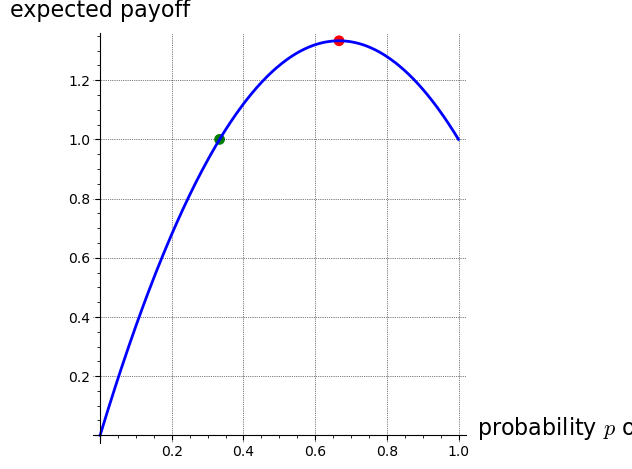

In [24]:
plot(expected_value, (p, 0, 1), thickness=2, gridlines=True,
     axes_labels=["probability $p$ of continuing", "expected payoff"]) \
    + point((p_star, value(p_star)), size=60, color="red") \
    + point((1/3, value(1/3)), size=60, color="green")

The red point is the optimal plan, the green one the point of indifference at a junction.

Gambit evaluated the plans; Sage found the function behind them and optimised it. Neither step works without the other.

## Summary

| Task | Call |
|---|---|
| New tree | `ExtensiveFormGame(players=[...])` |
| Wrap a PyGambit tree | `ExtensiveFormGame(game)` |
| Add a move | `game.append_move(node, player, actions)` |
| Add a move by chance | `game.append_chance_move(node, actions, probs)` |
| Bundle nodes into one information set | `game.append_infoset(node, like)` |
| Attach payoffs | `game.set_outcome(node, label, payoffs)` |
| Navigate | `game.root.children['action']` |
| Check the recall assumption | `game.is_perfect_recall` |
| Solve | `game.obtain_nash(algorithm='enumpure')` |
| Draw | `game.plot(backend='sage')`, `game.plot(backend='gtdraw')` |
| Read and write `.efg` | `game.load_efg(path)`, `game.save_efg(path)` |
| Catalog | `game.load_from_gambit_catalog()` |

Further reading:

- [SageMath game theory reference](https://doc.sagemath.org/html/en/reference/game_theory/index.html)
- [PyGambit API documentation](https://gambitproject.readthedocs.io/en/latest/pygambit.api.html)
- [Gambit's own extensive form tutorial](../02_extensive_form.ipynb)